Whats is persistance ?
Suppose we are doing chat on our chatbot and by mistake we exited olr we shut down the bot and tommorow again we need to use the same chat forn sa,e relenac so we could access it due to persisitance.

Benefit of persistnce?
Yes the imp one is fault tolernace :-
IF in our bot some system fails so it will use fallback staregy and other things could be worked


In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()
llm =  ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)

In [3]:
class JokeState(TypedDict):
    topic:str
    joke:str
    explanantion:str
    

In [4]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}


In [5]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}


In [6]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)


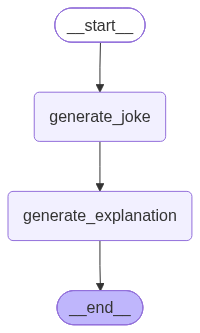

In [7]:
workflow

In [8]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)


{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄'}

In [9]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1bcf49-c518-69e2-8002-a0dfd96b0a0e'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-09-30T17:30:20.582755+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1bcf49-b4c5-6ea6-8001-68a15514bfaf'}}, tasks=(), interrupts=())

In [10]:
list(workflow.get_state_history(config1)) #intermidate state value (madhatale)



[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1bcf49-c518-69e2-8002-a0dfd96b0a0e'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-09-30T17:30:20.582755+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1bcf49-b4c5-6ea6-8001-68a15514bfaf'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1bcf49-b4c5-6ea6-8001-68a15514bfaf'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-09-30T17:30:18.871159+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': ''

In [11]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)


{'topic': 'pasta',
 'joke': 'Why did the spaghetti start a band?\n\nBecause it wanted to be a *fettuccine* rockstar—every time it hit a note, it *pasta* the beat!'}

In [12]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti start a band?\n\nBecause it wanted to be a *fettuccine* rockstar—every time it hit a note, it *pasta* the beat!'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1bcf49-d985-6dec-8002-f217b86946f8'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-09-30T17:30:22.724657+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1bcf49-cbc1-627f-8001-d101fa62ed60'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti start a band?\n\nBecause it wanted to be a *fettuccine* rockstar—every time it hit a note, it *pasta* the beat!'}, next=('generate_explanation',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1bcf49-cbc1-627f-8001-d101fa62ed60'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-09-30T17:

Like now we have learned how persisitenece state stored the history but currently its in my rAM so when we open and run our both again it will disaply so we will use datbase in future to stor query accordingly


Bemefits of persistance:
(1) Short term memory
(2) Fault tolerance
(3) Human in the loop
(4) Time travel


Fault tolerence :- Next up is we will understand the fault tolernvce what it is and undersatnd it How actually worlflows anre and system start after crash

Case Study: AI Customer Support Agent with Fault-Tolerant Payment API

Imagine an agent that handles a customer's payment-status query:

User
 ↓
Agent
 ↓
Check Payment API
 ↓
Generate Response

In [13]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [14]:
class PaymentState(TypedDict):
    customer_name: str
    payment_id: str
    payment_status: str
    api_failed: bool
    retry_count: int
    response: str

In [16]:
def payment_api(payment_id: str):
    
    # Simulate API failure
    if payment_id == "FAIL123":
        raise ConnectionError("Payment API is temporarily unavailable")

    return "SUCCESS"

In [17]:
def check_payment(state: PaymentState):

    print("Checking payment API...")

    try:
        status = payment_api(state["payment_id"])

        print("Payment API succeeded.")

        return {
            "payment_status": status,
            "api_failed": False
        }

    except Exception as e:

        print(f"API failed: {e}")

        return {
            "payment_status": "UNKNOWN",
            "api_failed": True
        }

In [18]:
def retry_payment(state: PaymentState):

    retry_count = state["retry_count"] + 1

    print(f"Retry attempt: {retry_count}")

    return {
        "retry_count": retry_count,
        "api_failed": False
    }

In [19]:
def generate_response(state: PaymentState):

    print("Generating final response...")

    return {
        "response": (
            f"Hello {state['customer_name']}, "
            f"your payment {state['payment_id']} "
            f"is {state['payment_status']}."
        )
    }

In [20]:
def fallback_response(state: PaymentState):

    print("Using fallback response.")

    return {
        "response": (
            f"Hello {state['customer_name']}, "
            f"we are currently unable to verify payment "
            f"{state['payment_id']}. "
            f"Please try again later."
        )
    }

In [21]:
def decide_after_api(state: PaymentState):

    if not state["api_failed"]:
        return "success"

    if state["retry_count"] < 3:
        return "retry"

    return "fallback"

In [22]:
builder = StateGraph(PaymentState)

In [23]:
builder.add_node("check_payment", check_payment)
builder.add_node("retry_payment", retry_payment)
builder.add_node("generate_response", generate_response)
builder.add_node("fallback_response", fallback_response)

In [24]:
builder.add_edge(START, "check_payment")

In [25]:
builder.add_conditional_edges(
    "check_payment",
    decide_after_api,
    {
        "success": "generate_response",
        "retry": "retry_payment",
        "fallback": "fallback_response"
    }
)

In [26]:
builder.add_edge("retry_payment", "check_payment")

In [27]:
builder.add_edge("generate_response", END)

builder.add_edge("fallback_response", END)

In [28]:
graph = builder.compile()

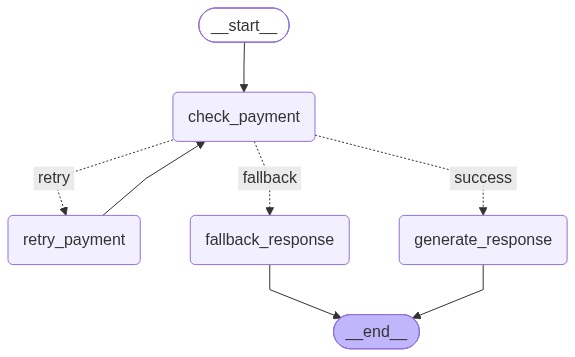

In [29]:
graph

Next up is Human-in-the-Loop in LangGraph — LinkedIn Post Case Study:AI generates a LinkedIn post, but before the post is published, a human must review and approve it.

Workflow:
                        ┌─────────────────┐
                    │ Generate Post   │
                    └────────┬────────┘
                             ↓
                    ┌─────────────────┐
                    │ Human Review    │
                    │      ⏸️         │
                    └────────┬────────┘
                             ↓
                  ┌─────────────────────┐
                  │ Human Decision      │
                  └─────────┬───────────┘
                       /     |      \
                      /      |       \
                 approve    edit    reject
                    ↓         ↓        ↓
                Publish    Revise     END
                              ↓
                         Human Review

Time Travel = going back to a previous checkpoint of a LangGraph execution, inspecting that state, and potentially continuing from that point.